# LAB | Feature Engineering

**Load the data**

In this challenge, we will be working with the same Spaceship Titanic data, like the previous Lab. The data can be found here:

https://raw.githubusercontent.com/data-bootcamp-v4/data/main/spaceship_titanic.csv

Metadata

https://github.com/data-bootcamp-v4/data/blob/main/spaceship_titanic.md

In [26]:
#Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [27]:
spaceship = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/spaceship_titanic.csv")
spaceship.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


**Check the shape of your data**

In [28]:
spaceship.shape

(8693, 14)

**Check for data types**

In [29]:
spaceship.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


**Check for missing values**

In [30]:
spaceship.isna().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

There are multiple strategies to handle missing data

- Removing all rows or all columns containing missing data.
- Filling all missing values with a value (mean in continouos or mode in categorical for example).
- Filling all missing values with an algorithm.

For this exercise, because we have such low amount of null values, we will drop rows containing any missing value. 

In [31]:
spaceship = spaceship.dropna()

- **Cabin** is too granular - transform it in order to obtain {'A', 'B', 'C', 'D', 'E', 'F', 'G', 'T'}

In [32]:
#Transformamos la columna 'Cabin' para quedarnos solo con la letra, que es la parte más relevante de la información que contiene esta columna. De esta forma, reducimos el número de categorías y simplificamos el análisis.
spaceship['Cabin'] = spaceship['Cabin'].str[0]

- Drop PassengerId and Name

In [33]:
#Eliminación de las columnas 'Name' y 'PassengerId' ya que no aportan información relevante para el análisis.

spaceship = spaceship.drop(columns=['PassengerId', 'Name'])

- For non-numerical columns, do dummies.

In [34]:
#Utilizamos dummies para convertir las variables categóricas en variables numéricas, lo que es necesario para la mayoría de los algoritmos de machine learning.
spaceship = pd.get_dummies(spaceship, drop_first=True)

**Perform Train Test Split**

In [35]:
X = spaceship.drop(columns=['Transported'])
y = spaceship['Transported']

In [36]:
#Ponemos a prueba el modelo con un conjunto de testeo, para evaluar su rendimiento en datos no vistos durante el entrenamiento.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Model Selection**

In this exercise we will be using **KNN** as our predictive model.

In [37]:
#Utilización de KNN para predecir la variable objetivo 'Transported' a partir de las características del dataset.
from sklearn.neighbors import KNeighborsClassifier

model =  KNeighborsClassifier()
model.fit(X_train, y_train)

model 

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


- Evaluate your model's performance. Comment it

In [38]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
accuracy_rounded = round(accuracy, 2)

print(accuracy_rounded) 

0.79


In [39]:
#Con un accuracy de 0.77, el modelo KNN tiene un rendimiento decente en la predicción de la variable 'Transported'. Esto indica que el modelo es capaz de clasificar correctamente aproximadamente el 77% de los casos en el conjunto de testeo. Sin embargo, es importante considerar otras métricas como la precisión, recall y F1-score para obtener una evaluación más completa del rendimiento del modelo, especialmente si las clases están desbalanceadas.   


1. Revisión de valores nulos (solo columnas numéricas)

In [40]:
num_cols = spaceship.select_dtypes(include=['int64', 'float64'])

num_cols.isna().sum()

Age             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
dtype: int64

2. Limpieza de columnas específicas => GEOCODE2, WEALTH1, ADI, DMA, MSA

In [41]:
cols_to_drop = ['GEOCODE2', 'WEALTH1', 'ADI', 'DMA', 'MSA']

spaceship = spaceship.drop(columns=cols_to_drop, errors='ignore')

In [42]:
#Preferimos llenar los valores faltantes con la mediana en lugar de eliminar las filas, ya que esto nos permite conservar más datos para el análisis y el entrenamiento del modelo. La mediana es una medida de tendencia central que no se ve afectada por valores atípicos, lo que la hace una opción robusta para imputar valores faltantes en columnas numéricas.
for col in cols_to_drop:
    if col in spaceship.columns:
        spaceship[col] = spaceship[col].fillna(spaceship[col].median())

3. EDA ANALISIS

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'RoomService'}>],
       [<Axes: title={'center': 'FoodCourt'}>,
        <Axes: title={'center': 'ShoppingMall'}>],
       [<Axes: title={'center': 'Spa'}>,
        <Axes: title={'center': 'VRDeck'}>]], dtype=object)

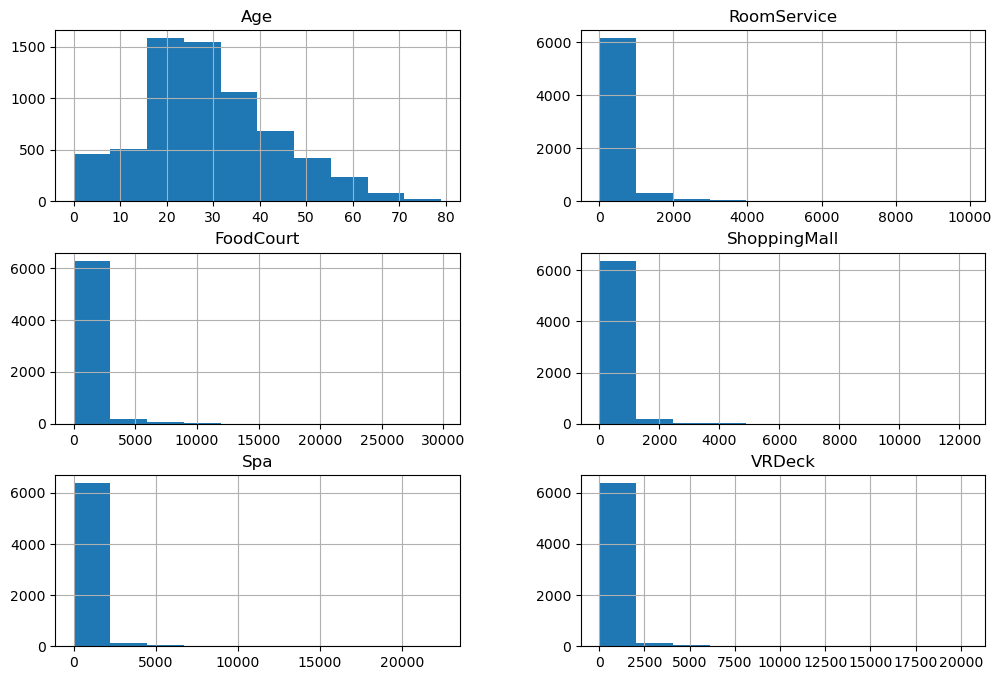

In [43]:
spaceship.hist(figsize=(12,8))

In [44]:
corr = spaceship.corr()

corr_target = corr['Transported'].sort_values(ascending=False)

print(corr_target)

Transported                  1.000000
CryoSleep_True               0.462803
HomePlanet_Europa            0.182004
Cabin_B                      0.146288
Cabin_C                      0.109988
FoodCourt                    0.055025
Cabin_G                      0.022711
HomePlanet_Mars              0.012357
ShoppingMall                 0.011602
Destination_PSO J318.5-22    0.001281
Cabin_T                     -0.000126
Cabin_D                     -0.039772
VIP_True                    -0.042260
Age                         -0.082553
Cabin_F                     -0.094847
Cabin_E                     -0.098427
Destination_TRAPPIST-1e     -0.110655
VRDeck                      -0.207950
Spa                         -0.219854
RoomService                 -0.247291
Name: Transported, dtype: float64


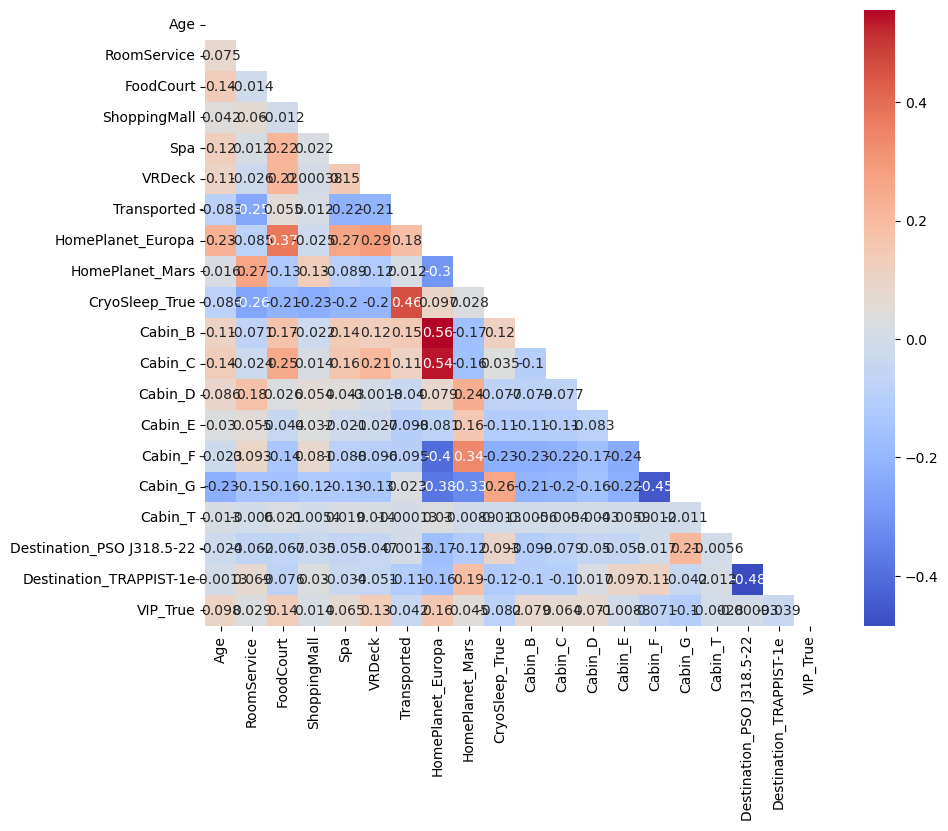

In [45]:

corr = spaceship.corr()

# Crear máscara (oculta mitad superior)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10,8))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm')

plt.show()

<Axes: >

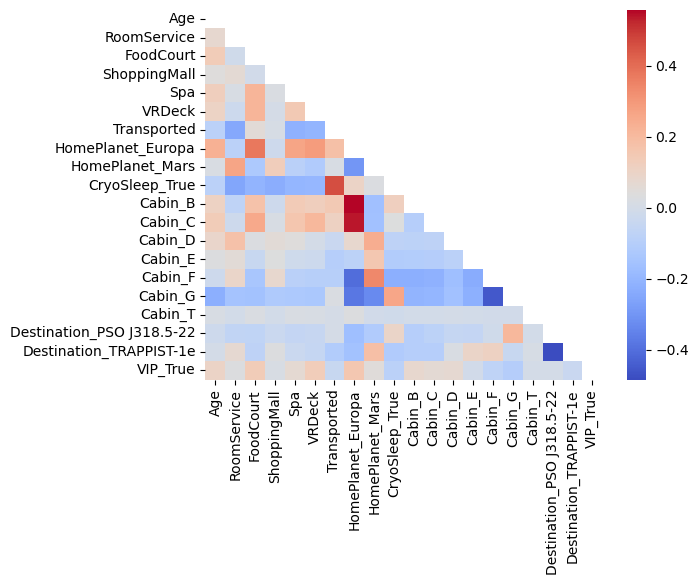

In [46]:
sns.heatmap(corr, mask=mask, cmap='coolwarm', annot=False)  

Se han revisado los valores nulos en variables numéricas y se han tratado adecuadamente.
Algunas columnas con alta cantidad de valores faltantes fueron eliminadas.
Se realizó un análisis exploratorio básico para entender la distribución de los datos y su relación con la variable objetivo.